# 🎂 나이 인식 프로그램 v2
### 50대 이상(senior) / 50대 미만(young, 10대 포함) 이진 분류
---

## 1단계: Roboflow 데이터셋 불러오기

In [1]:
!pip install roboflow -q

from roboflow import Roboflow

# ⚠️ 아래 api_key를 본인 키로 교체하세요!
rf = Roboflow(api_key="3v2NsaCn9lgONw9a7907")
project = rf.workspace("sjh051217-gmail-com").project("age-detection-mgmcv")
version = project.version(2)
dataset = version.download("folder")

print("✅ 데이터셋 v2 다운로드 완료!")
print(f"데이터셋 경로: {dataset.location}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to age-detection-2 in folder:: 100%|██████████| 207/207 [00:00<00:00, 8543.55it/s]

✅ 데이터셋 v2 다운로드 완료!
데이터셋 경로: /content/age-detection-2


## 2단계: 라이브러리 임포트 및 GPU 확인

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image

# GPU 대신 CPU 강제 사용 (CUDA 에러 방지)
device = torch.device("cpu")
print(f"✅ 사용 디바이스: {device}")

✅ 사용 디바이스: cpu


## 3단계: 클래스 확인 및 이진 분류용 커스텀 데이터셋 설정

In [3]:
dataset_path = dataset.location
train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "valid")
test_dir  = os.path.join(dataset_path, "test")

# 클래스 확인
all_classes = sorted(os.listdir(train_dir))
print("전체 클래스 목록:", all_classes)

# 이미지 수 확인
for split, path in [("Train", train_dir), ("Valid", valid_dir), ("Test", test_dir)]:
    if os.path.exists(path):
        for cls in os.listdir(path):
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                count = len(os.listdir(cls_path))
                print(f"[{split}] {cls}: {count}장")

전체 클래스 목록: ['junior', 'senior', 'young']
[Train] junior: 42장
[Train] young: 33장
[Train] senior: 105장
[Valid] junior: 4장
[Valid] young: 3장
[Valid] senior: 10장
[Test] junior: 2장
[Test] young: 1장
[Test] senior: 5장


## 4단계: 커스텀 데이터셋 (senior vs young 이진 분류)

In [4]:
class BinaryAgeDataset(Dataset):
    """
    senior 폴더 → 라벨 1 (50대 이상)
    그 외 모든 폴더(young, 10대 등) → 라벨 0 (50대 미만)
    """
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.data = []
        for cls in os.listdir(root_dir):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            label = 1 if cls.lower() == "senior" else 0
            for img_file in os.listdir(cls_path):
                if img_file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                    self.data.append((os.path.join(cls_path, img_file), label))
        print(f"총 {len(self.data)}장 로드 완료")
        print(f"  senior(1): {sum(1 for _,l in self.data if l==1)}장")
        print(f"  young(0):  {sum(1 for _,l in self.data if l==0)}장")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("=== Train ===")
train_dataset = BinaryAgeDataset(train_dir, transform=train_transform)
print("=== Valid ===")
valid_dataset = BinaryAgeDataset(valid_dir, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)

print("\n✅ 데이터 로더 준비 완료!")

=== Train ===
총 180장 로드 완료
  senior(1): 105장
  young(0):  75장
=== Valid ===
총 17장 로드 완료
  senior(1): 10장
  young(0):  7장

✅ 데이터 로더 준비 완료!


## 5단계: 모델 설정 (MobileNetV2 전이학습)

In [5]:
model = models.mobilenet_v2(pretrained=True)
model.classifier[1] = nn.Linear(model.last_channel, 2)  # 이진 분류 (senior / young)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("✅ 모델 준비 완료!")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
100%|██████████| 13.6M/13.6M [00:00<00:00, 145MB/s]

✅ 모델 준비 완료!


## 6단계: 모델 학습

In [6]:
EPOCHS = 10
train_losses, valid_losses = [], []
train_accs,   valid_accs   = [], []
best_acc = 0.0

for epoch in range(EPOCHS):
    # --- 학습 ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    # --- 검증 ---
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            v_loss    += loss.item()
            _, predicted = outputs.max(1)
            v_correct += predicted.eq(labels).sum().item()
            v_total   += labels.size(0)
    valid_losses.append(v_loss / len(valid_loader))
    v_acc = 100. * v_correct / v_total
    valid_accs.append(v_acc)

    if v_acc > best_acc:
        best_acc = v_acc
        torch.save(model.state_dict(), "best_model_v2.pth")

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.1f}% | "
          f"Valid Loss: {valid_losses[-1]:.4f} Acc: {v_acc:.1f}%")

print(f"\n✅ 학습 완료! 최고 검증 정확도: {best_acc:.1f}%")

Epoch [01/10] Train Loss: 0.4980 Acc: 81.7% | Valid Loss: 0.6901 Acc: 76.5%
Epoch [02/10] Train Loss: 0.2038 Acc: 93.3% | Valid Loss: 0.1100 Acc: 94.1%
Epoch [03/10] Train Loss: 0.1996 Acc: 95.6% | Valid Loss: 0.1326 Acc: 88.2%
Epoch [04/10] Train Loss: 0.1901 Acc: 92.8% | Valid Loss: 0.6015 Acc: 76.5%
Epoch [05/10] Train Loss: 0.1323 Acc: 92.8% | Valid Loss: 0.2720 Acc: 82.4%
Epoch [06/10] Train Loss: 0.1201 Acc: 94.4% | Valid Loss: 0.0340 Acc: 94.1%
Epoch [07/10] Train Loss: 0.1109 Acc: 95.6% | Valid Loss: 0.2986 Acc: 82.4%
Epoch [08/10] Train Loss: 0.0722 Acc: 96.1% | Valid Loss: 0.1167 Acc: 88.2%
Epoch [09/10] Train Loss: 0.0460 Acc: 99.4% | Valid Loss: 0.0595 Acc: 94.1%
Epoch [10/10] Train Loss: 0.0115 Acc: 100.0% | Valid Loss: 0.0502 Acc: 100.0%

✅ 학습 완료! 최고 검증 정확도: 100.0%


## 7단계: 학습 결과 시각화

Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.


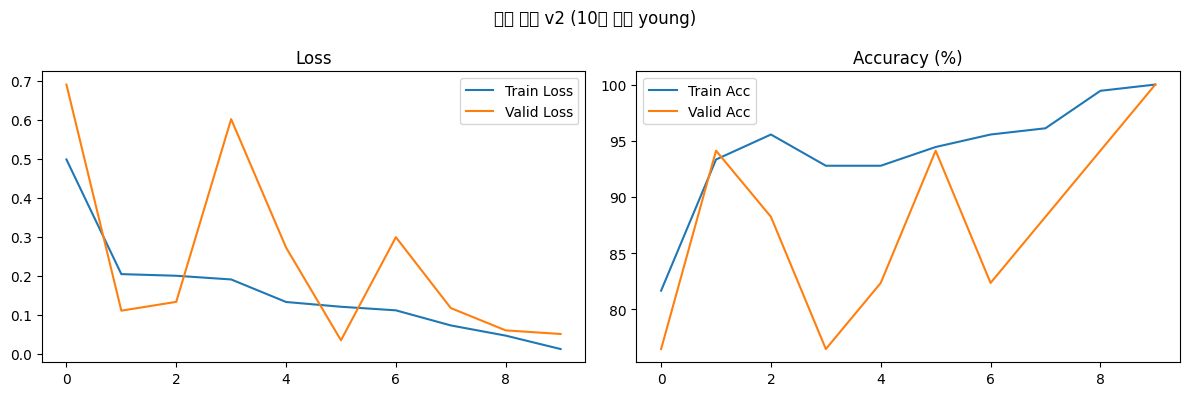

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(valid_losses, label="Valid Loss")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(train_accs, label="Train Acc")
ax2.plot(valid_accs, label="Valid Acc")
ax2.set_title("Accuracy (%)")
ax2.legend()

plt.suptitle("나이 인식 v2 (10대 포함 young)")
plt.tight_layout()
plt.show()

## 8단계: 새 이미지로 테스트

In [10]:
def predict(image_path):
    model.load_state_dict(torch.load("best_model_v2.pth", map_location=device))
    model.eval()

    img = Image.open(image_path).convert("RGB")
    img_tensor = valid_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
        pred    = probs.argmax().item()

    label      = "senior" if pred == 1 else "young"
    confidence = probs[pred].item() * 100

    print(f"결과: {'50대 이상 (senior)' if label == 'senior' else '50대 미만 (young)'}")
    print(f"신뢰도: {confidence:.1f}%")

    plt.imshow(img)
    plt.title(f"{label} ({confidence:.1f}%)")
    plt.axis("off")
    plt.show()

# ⚠️ 테스트할 이미지 경로를 입력하세요
# predict("/content/test_image.jpg")
